In [1]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

df = pd.read_csv('Car_Price_Prediction.csv')
df.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   object 
 1   Model         1000 non-null   object 
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   object 
 6   Transmission  1000 non-null   object 
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


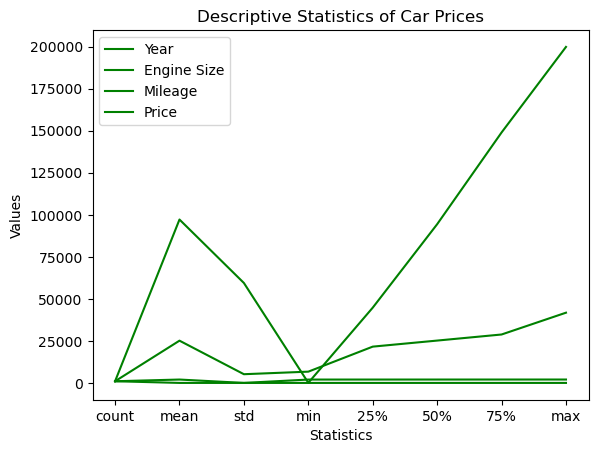

In [4]:
df.describe().plot(kind='line',color='g')
plt.title('Descriptive Statistics of Car Prices')
plt.xlabel('Statistics')
plt.ylabel('Values')
plt.show()

In [5]:
df.isnull().sum()

Make            0
Model           0
Year            0
Engine Size     0
Mileage         0
Fuel Type       0
Transmission    0
Price           0
dtype: int64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


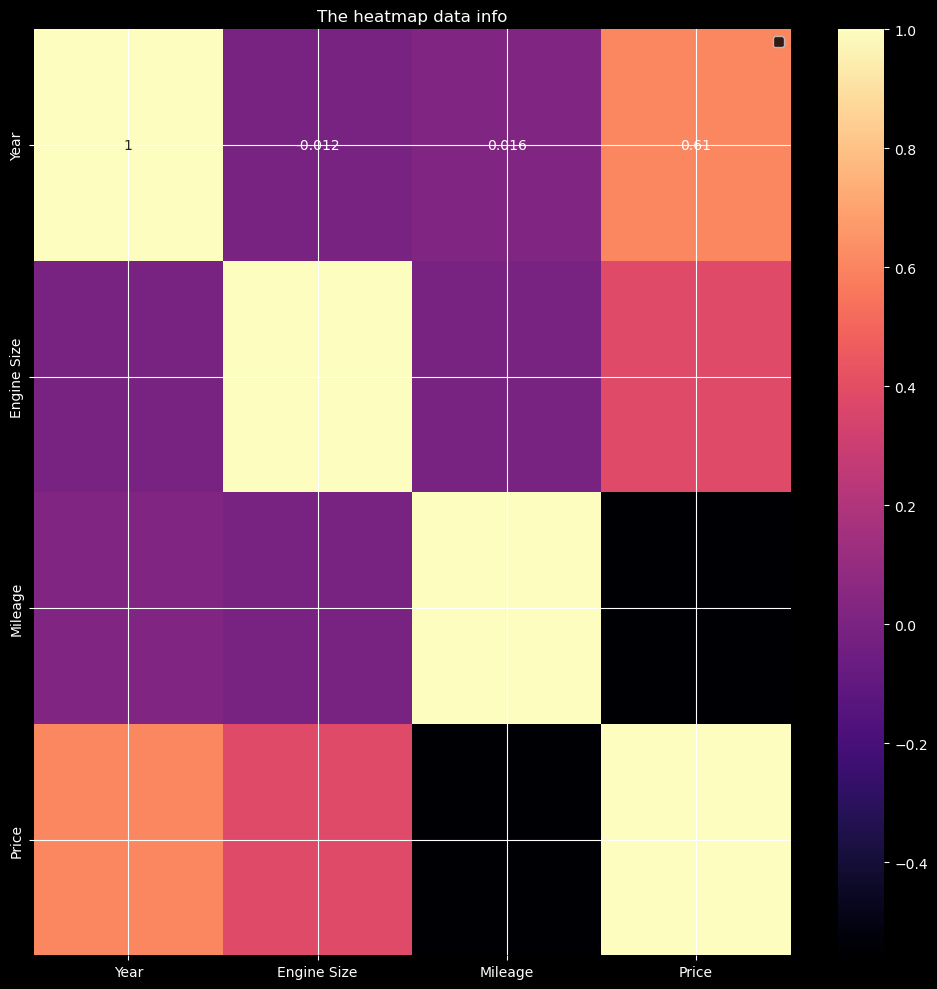

In [8]:
plt.figure(figsize=(10,10))
plt.style.use('dark_background')
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='magma')
plt.title('The heatmap data info')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


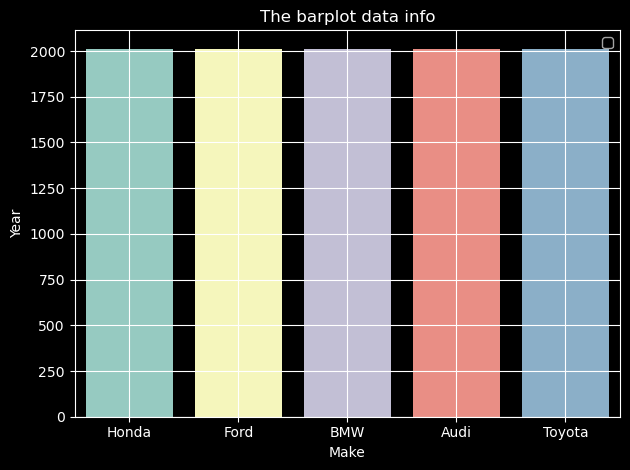

In [9]:
plt.style.use('dark_background')
sns.barplot(x='Make',y='Year',data=df)
plt.title('The barplot data info')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

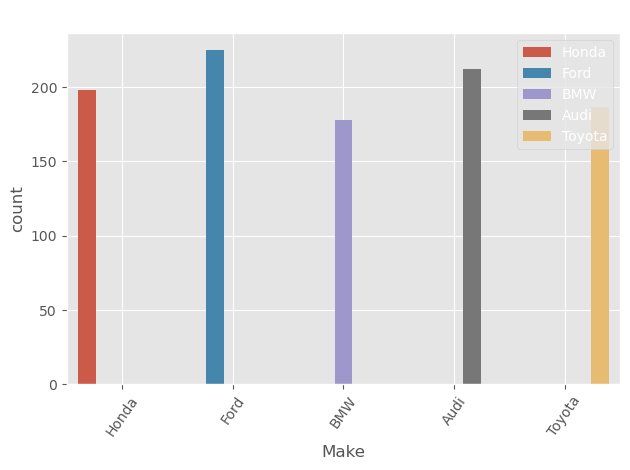

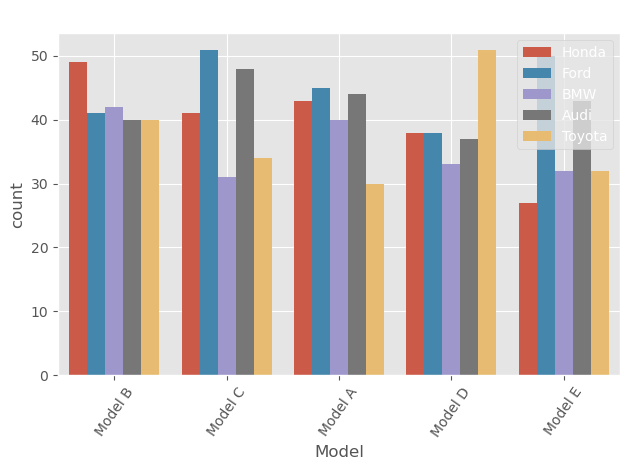

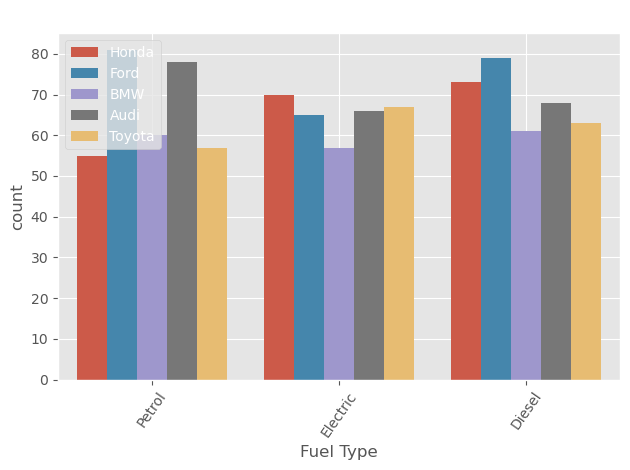

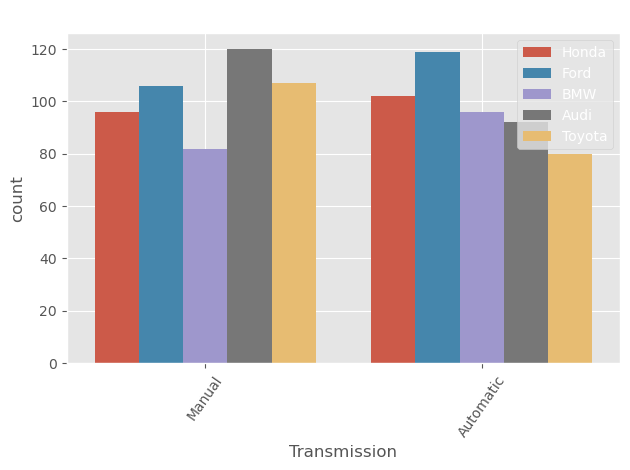

In [10]:
category_col = df.select_dtypes(include='object').columns 

plt.style.use('ggplot')
for col in category_col:
    sns.countplot(x=col,data=df,hue='Make')
    plt.xticks(rotation=55)
    plt.title(f'The countplot data {col} info')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


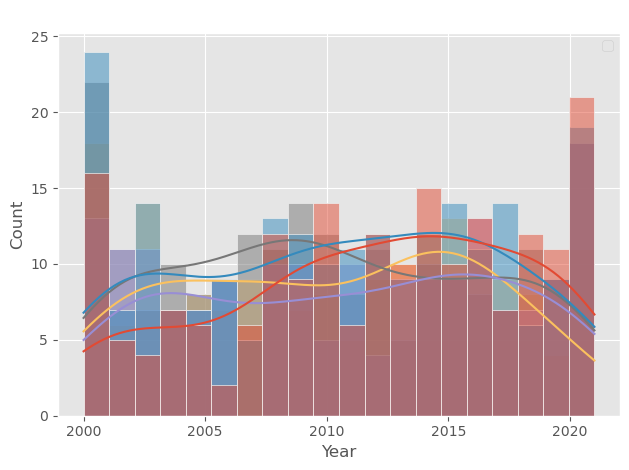

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


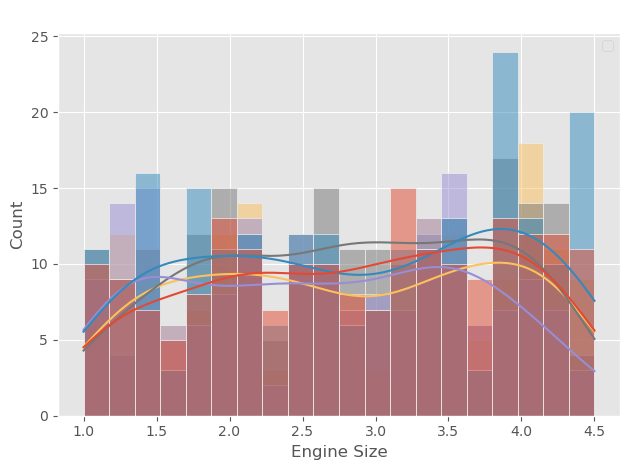

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


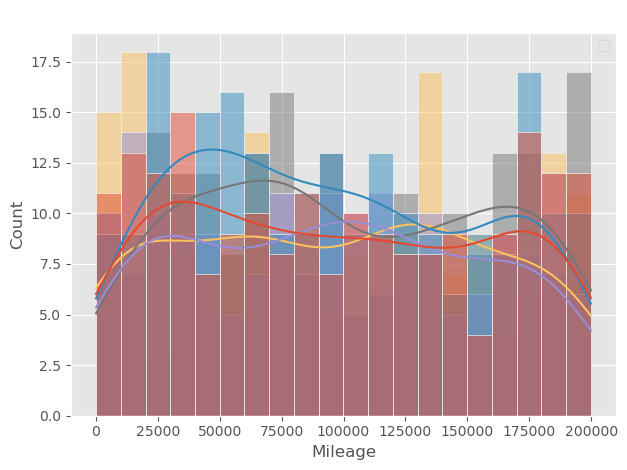

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


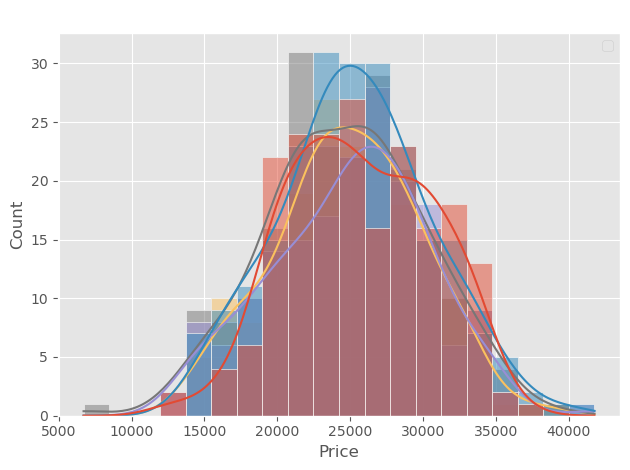

In [11]:
numerical_col = df.select_dtypes(include=np.number).columns 

plt.style.use('ggplot')
for col in numerical_col:
    sns.histplot(data=df,x=col,kde=True,bins=20,hue='Make')
    plt.title(f'The histplot data {col} info')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


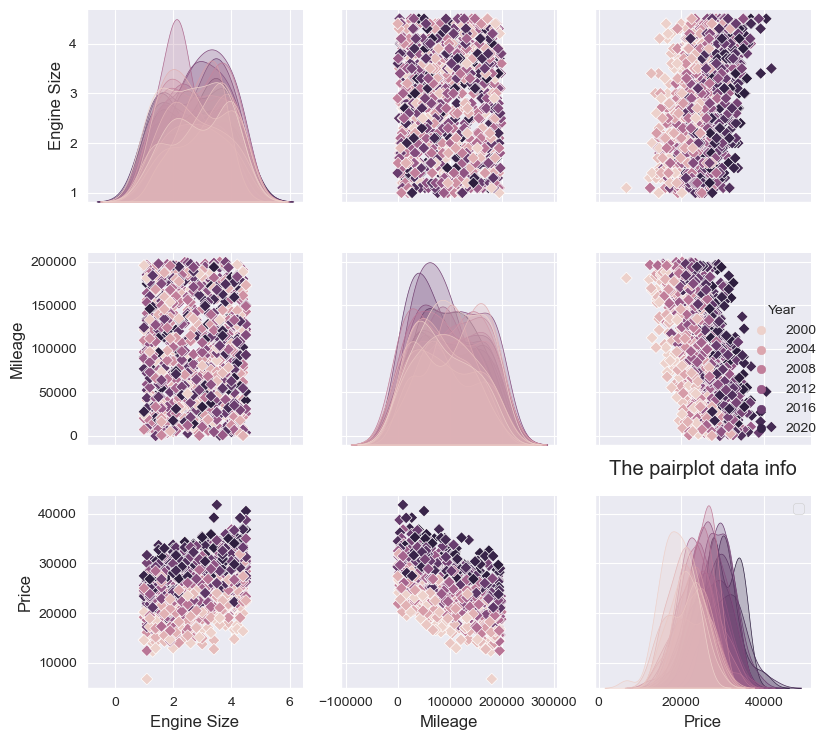

In [12]:
sns.set_style('darkgrid')
sns.pairplot(data=df,markers='D',hue='Year')
plt.title('The pairplot data info')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


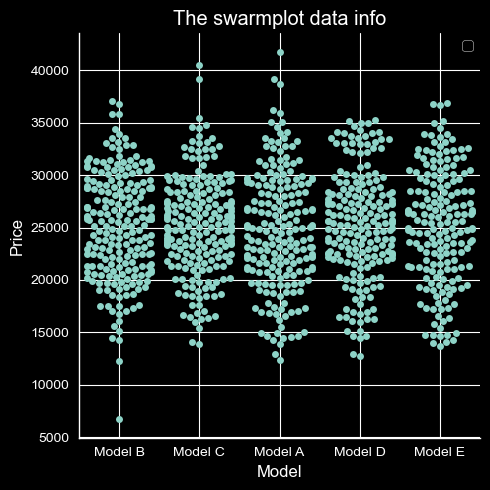

In [13]:
plt.style.use('dark_background')
sns.catplot(kind='swarm',data=df,x='Model',y='Price')
plt.title('The swarmplot data info')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


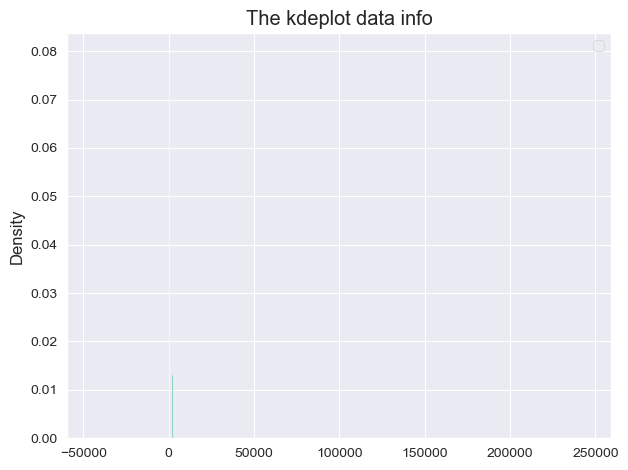

In [14]:
sns.set_style('darkgrid')
sns.kdeplot(data=df,fill=True)
plt.title('The kdeplot data info')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


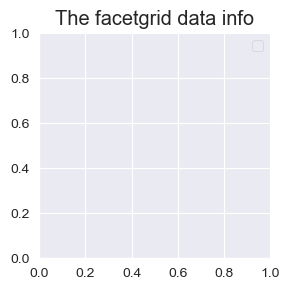

In [15]:
sns.set_style('darkgrid')
sns.FacetGrid(data=df)
plt.title('The facetgrid data info')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

X = df[['Year','Engine Size','Mileage']]
y = df['Price']

x_train,x_test,y_train,y_test = train_test_split(X,y, random_state=42,test_size=0.3)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
y_pred

array([25724.43766052, 29624.09238406, 26884.92429277, 27496.67443102,
       27825.82158155, 19341.21733807, 22923.58388515, 27444.73584101,
       30746.67432523, 24286.1512086 , 28688.13802879, 22053.95176099,
       18662.28665039, 26479.33501764, 24505.22822298, 28094.11144732,
       21300.38255118, 27304.52952207, 24315.22457505, 30723.87859104,
       21685.7588633 , 22293.40189627, 16947.31758361, 22643.62971779,
       16647.62214978, 26213.31881344, 28490.81685016, 21445.52084619,
       22789.1487143 , 29930.2037013 , 19834.30433296, 24187.3269422 ,
       22260.34663196, 34095.81783584, 29655.69707351, 29391.12260305,
       18556.96661043, 29070.98842694, 30766.33045293, 24248.81478909,
       31222.58810881, 26457.66070141, 28967.5970575 , 25431.61721176,
       21215.38271257, 21403.21972581, 32399.05035182, 32828.51043774,
       25393.96935002, 22019.71425142, 32146.59060392, 21381.29641831,
       23999.14784581, 19023.02129992, 21529.23576518, 27217.42282197,
      

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


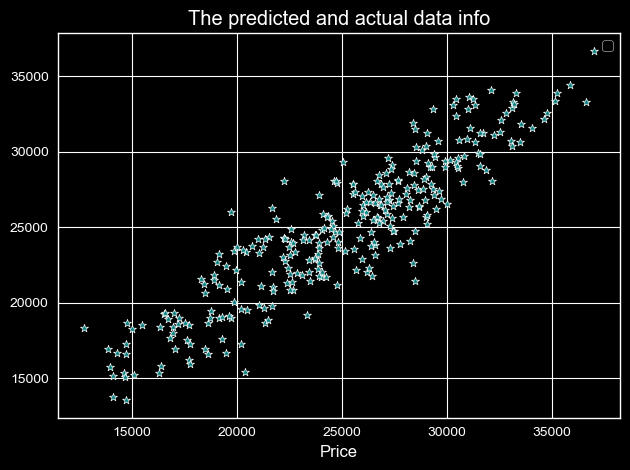

In [21]:
plt.style.use('dark_background')
sns.scatterplot(x=y_test,y=y_pred,marker='*',color='teal')
plt.title('The predicted and actual data info')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


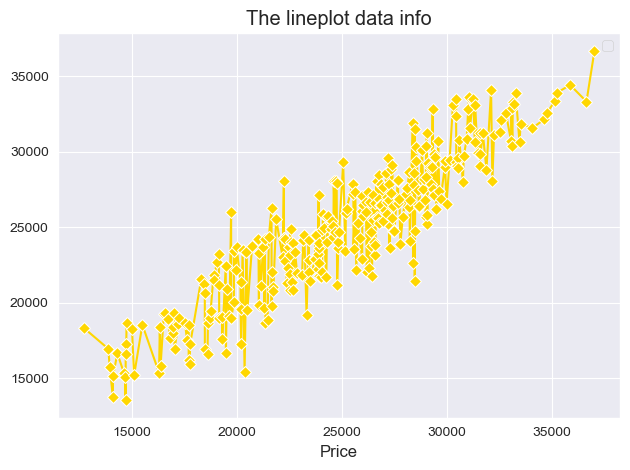

In [22]:
sns.set_style('darkgrid')
sns.lineplot(x=y_test,y=y_pred,marker='D',color='gold')
plt.title('The lineplot data info')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)

print('the mean absolute error:',mae)
print('The mean squared error:',mse)
print('the score is :',score)

the mean absolute error: 1703.976400011932
The mean squared error: 4520798.57866538
the score is : 0.8267777180090565
